In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('/content/DataAnalyst.csv')
df.shape

(2253, 16)

In [2]:
df = df.drop(columns=['Unnamed: 0', 'Competitors', 'Easy Apply'])
df = df.dropna()
df.shape

(2252, 13)

In [3]:
df[['Salary_Min', 'Salary_Max']] = df['Salary Estimate'].str.extract(r'\$(\d+)K-\$(\d+)K').astype(float)
df['Salary_Avg'] = (df['Salary_Min'] + df['Salary_Max']) / 2
df = df.drop('Salary Estimate', axis=1)

In [4]:
skills = {
    'SQL': ['sql', 'mysql', 'postgresql', 't-sql', 'tsql', 'pl/sql'],
    'Python': ['python', 'pandas', 'numpy', 'scikit'],
    'R': [' r ', ' r,', ' r.', 'rstudio', 'ggplot', ' r)'],
    'Excel': ['excel', 'spreadsheet', 'vba'],
    'Tableau': ['tableau'],
    'Power_BI': ['power bi', 'powerbi', 'power-bi'],
    'SAS': ['sas '],
    'Machine_Learning': ['machine learning', 'ml', 'deep learning', 'neural network', 'scikit-learn'],
    'Statistics': ['statistics', 'statistical', 'regression', 'hypothesis'],
    'AWS': ['aws', 'amazon web services', 's3', 'ec2'],
    'Spark': ['spark', 'pyspark'],
    'Java': ['java '],
    'Azure': ['azure', 'microsoft cloud']
}

def check_skill(text, keywords):
    if pd.isna(text):
        return 0
    text_lower = text.lower()
    for kw in keywords:
        if kw in text_lower:
            return 1
    return 0

for skill_name, keywords in skills.items():
    df[skill_name] = df['Job Description'].apply(lambda x: check_skill(x, keywords))

In [5]:
df[['City', 'State']] = df['Location'].str.split(',', n=1, expand=True)
df['State'] = df['State'].str.strip()

In [6]:
def categorize_seniority(title):
    if pd.isna(title):
        return 'Unknown'
    title_lower = title.lower()
    if any(word in title_lower for word in ['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff', 'manager']):
        return 'Senior'
    elif any(word in title_lower for word in ['junior', 'jr.', 'jr ', 'entry', 'associate', 'intern']):
        return 'Entry Level'
    else:
        return 'Mid Level'

df['Seniority'] = df['Job Title'].apply(categorize_seniority)
df['Seniority'].value_counts()

,count
Seniority,
Mid Level,1638
Senior,504
Entry Level,110


In [7]:
skill_cols = ['SQL', 'Python', 'R', 'Excel', 'Tableau', 'Power_BI',
              'SAS', 'Machine_Learning', 'Statistics', 'AWS', 'Spark', 'Java', 'Azure']

seniority_map = {'Entry Level': 0, 'Mid Level': 1, 'Senior': 2}
df['Seniority_Encoded'] = df['Seniority'].map(seniority_map)

top_states = df['State'].value_counts().head(10).index.tolist()
df['State_Grouped'] = df['State'].apply(lambda x: x if x in top_states else 'Other')
df['State_Encoded'] = LabelEncoder().fit_transform(df['State_Grouped'])

cluster_features = df[skill_cols + ['Seniority_Encoded', 'State_Encoded', 'Salary_Avg']].dropna()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(cluster_features)

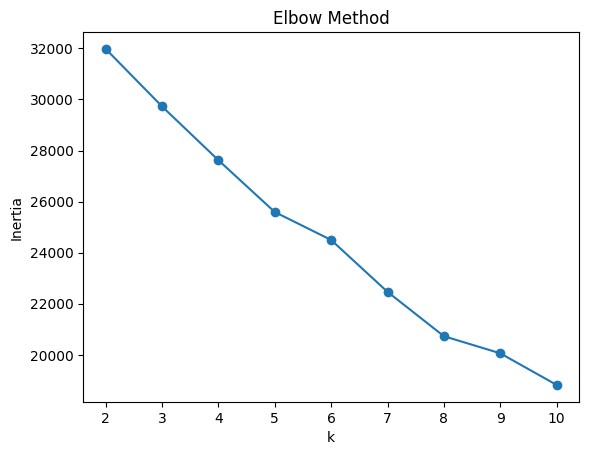

In [8]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[cluster_features.index, 'Cluster'] = kmeans.fit_predict(features_scaled)

In [10]:
for c in range(4):
    subset = df[df['Cluster'] == c]
    top_skills = subset[skill_cols].mean().sort_values(ascending=False).head(3)
    print(f"Cluster {c}: {len(subset)} jobs, ${subset['Salary_Avg'].mean():.0f}K avg")
    print(f"  {subset['Seniority'].mode().values[0]}, top skills: {', '.join(top_skills.index)}\n")

Cluster 0: 155 jobs, $70K avg
  Mid Level, top skills: SAS, SQL, Excel

Cluster 1: 1335 jobs, $72K avg
  Mid Level, top skills: Excel, SQL, Statistics

Cluster 2: 672 jobs, $74K avg
  Mid Level, top skills: SQL, Python, Excel

Cluster 3: 89 jobs, $72K avg
  Mid Level, top skills: Spark, SQL, Python



In [11]:
columns_for_tableau = [
    'Job Title', 'Salary_Min', 'Salary_Max', 'Salary_Avg',
    'Company Name', 'Location', 'City', 'State',
    'Rating', 'Size', 'Sector', 'Industry', 'Seniority', 'Cluster',
    'SQL', 'Python', 'R', 'Excel', 'Tableau', 'Power_BI',
    'SAS', 'Machine_Learning', 'Statistics', 'AWS', 'Spark', 'Java', 'Azure'
]

df[columns_for_tableau].to_csv('DataAnalyst_Final.csv', index=False)

from google.colab import files
files.download('DataAnalyst_Final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>